In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib_venn import venn2

Total de títulos en OpenAlex: 134
Total de títulos en Scopus: 108
Total de títulos duplicados: 77
Total de títulos en Scopus que no están en OpenAlex: 31
Total de títulos en OpenAlex que no están en Scopus: 57


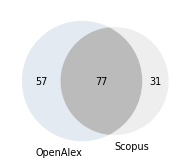

In [2]:
 

 

# Leer los archivos CSV
df_openalex = pd.read_csv('data/OpenAlex_seismic_waves_both.csv')
df_scopus = pd.read_csv('data/Scopus_seismic_waves_both.csv')

# Crear conjuntos de títulos para cada DataFrame
set_openalex = set(df_openalex['Title'])
set_scopus = set(df_scopus['Title'])

# Identificar títulos duplicados
duplicated_titles = set_openalex & set_scopus

# DataFrame con títulos duplicados (desde OpenAlex)
duplicated_df = df_openalex[df_openalex['Title'].isin(duplicated_titles)]

# Títulos únicos en cada base de datos
titles_in_openalex_not_in_scopus = set_openalex - set_scopus
titles_in_scopus_not_in_openalex = set_scopus - set_openalex

# Guardar títulos duplicados
duplicated_titles_df = pd.DataFrame(sorted(duplicated_titles), columns=['Title'])
duplicated_titles_df.to_csv('data/duplicated_titles.csv', index=False)

# Guardar títulos únicos de OpenAlex
openalex_unique_df = df_openalex[
    df_openalex['Title'].isin(titles_in_openalex_not_in_scopus)
][['Title']]
openalex_unique_df.to_csv('data/titles_openalex_not_in_scopus.csv', index=False)

# Guardar títulos únicos de Scopus
scopus_unique_df = df_scopus[
    df_scopus['Title'].isin(titles_in_scopus_not_in_openalex)
][['Title']]
scopus_unique_df.to_csv('data/titles_scopus_not_in_openalex.csv', index=False)

# Imprimir totales
print(f"Total de títulos en OpenAlex: {len(set_openalex)}")
print(f"Total de títulos en Scopus: {len(set_scopus)}")
print(f"Total de títulos duplicados: {len(duplicated_titles)}")
print(f"Total de títulos en Scopus que no están en OpenAlex: {len(titles_in_scopus_not_in_openalex)}")
print(f"Total de títulos en OpenAlex que no están en Scopus: {len(titles_in_openalex_not_in_scopus)}")

color_forward = '#b9cbe0ff'   # blue w/ alpha
color_inverse = '#d6d6d683'   # gray w/ alpha

# Figure 
fig, ax = plt.subplots(figsize=(2.2, 2.2))

v = venn2(
    [set_openalex, set_scopus],
    set_labels=('OpenAlex', 'Scopus'),
    ax=ax
)

v.get_patch_by_id('10').set_color(color_forward)
v.get_patch_by_id('01').set_color(color_inverse)
v.get_patch_by_id('11').set_color('#55555580')   

for pid in ['10', '01', '11']:
    patch = v.get_patch_by_id(pid)
    if patch:
        patch.set_edgecolor('none')

for text in v.set_labels:
    if text:
        text.set_fontsize(7)

for text in v.subset_labels:
    if text:
        text.set_fontsize(7)

ax.set_axis_off()

# Save  
plt.savefig(
    'figs/duplicates.svg',
    bbox_inches='tight'
)
plt.show()
 
#%%

df_manual = pd.read_csv('data/Manually filtered.csv')
item_types = df_manual['Item Type'].dropna()
item_type_counts = item_types.value_counts()

color_forward = '#b9cbe0ff'
color_inverse = '#d6d6d683'
bar_width = 0.35

#Read data 
df_manual_forward = pd.read_csv('data/Manually_filtered_forward.csv')
df_manual_inverse = pd.read_csv('data/Manually_filtered_inverse.csv')

# Combine & deduplicate 
combined_df = pd.concat([df_manual_forward, df_manual_inverse], ignore_index=True)
combined_df_unique = combined_df.drop_duplicates(subset='Title')

# Normalize Item Type 
item_type_map = {
    'journalArticle': 'Journal article',
    'conferencePaper': 'Conference paper',
    'preprint': 'Preprint',
    'bookSection': 'Book chapter',
    'thesis': 'Thesis',
    'report': 'Report'
}

combined_df_unique['Item Type (clean)'] = (
    combined_df_unique['Item Type']
    .map(item_type_map)
    .fillna(combined_df_unique['Item Type'])
)

item_type_counts = combined_df_unique['Item Type (clean)'].value_counts()

# Publication counts 
forward_counts = df_manual_forward['Publication Year'].value_counts().sort_index()
inverse_counts = df_manual_inverse['Publication Year'].value_counts().sort_index()

years = sorted(set(forward_counts.index).union(inverse_counts.index))
forward_vals = [forward_counts.get(y, 0) for y in years]
inverse_vals = [inverse_counts.get(y, 0) for y in years]
x = np.array(years)



In [3]:
# Count publication titles
publication_counts = df_manual["Publication Title"].value_counts()

# Top 4 most common journals
top_4_publications = publication_counts.head(4)

# Store names and counts in variables
top_publication_names = top_4_publications.index.tolist()
top_publication_values = top_4_publications.values.tolist()

print(top_4_publications)

Publication Title
IEEE Transactions on Geoscience and Remote Sensing    7
Geophysics                                            3
Acta Geophysica                                       2
Geophysical Journal International                     2
Name: count, dtype: int64


In [18]:
top_publication_names

journal_short = [
    "IEEE TGRS",
    "Geophysics",
    "Acta Geophysica",
    "GJI"
]

In [19]:
top_publication_names = journal_short

In [20]:
top_publication_values

[7, 3, 2, 2]

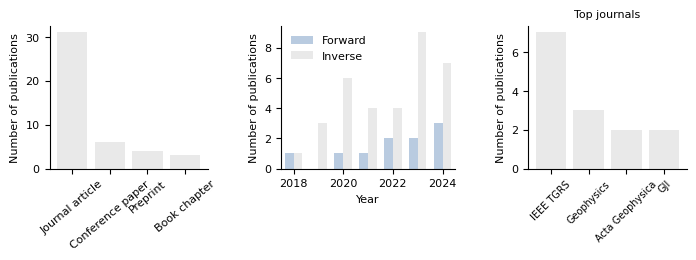

In [25]:
# Figure
fig = plt.figure(figsize=(7.0, 2.2))
gs = GridSpec(1, 3, width_ratios=[1, 1.1, 1], figure=fig)

fig.subplots_adjust(
    left=0.07,
    right=0.98,
    bottom=0.30,
    top=0.95,
    wspace=0.45
)

# Panel 1: Item types
ax1 = fig.add_subplot(gs[0, 0])

ax1.bar(
    item_type_counts.index,
    item_type_counts.values,
    color=color_inverse
)

ax1.set_ylabel("Number of publications", fontsize=8)
ax1.tick_params(axis='x', rotation=40, labelsize=8)
ax1.tick_params(axis='y', labelsize=8)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Panel 2: Publications per year
ax2 = fig.add_subplot(gs[0, 1])

ax2.bar(
    x - bar_width/2,
    forward_vals,
    width=bar_width,
    color=color_forward,
    label='Forward'
)

ax2.bar(
    x + bar_width/2,
    inverse_vals,
    width=bar_width,
    color=color_inverse,
    label='Inverse'
)

ax2.set_xlabel("Year", fontsize=8)
ax2.set_ylabel("Number of publications", fontsize=8)

ax2.set_xticks(np.arange(min(years), max(years)+1, 2))
ax2.set_xlim(min(years)-0.5, max(years)+0.5)

ax2.tick_params(axis='both', labelsize=8)

ax2.legend(
    frameon=False,
    fontsize=8,
    loc='upper left'
)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Panel 3: Top publication titles
ax3 = fig.add_subplot(gs[0, 2])

ax3.bar(
    top_publication_names,
    top_publication_values,
    color=color_inverse
)

ax3.set_title("Top journals", fontsize=8)
ax3.set_ylabel("Number of publications", fontsize=8)

ax3.tick_params(axis='x', rotation=45, labelsize=7)
ax3.tick_params(axis='y', labelsize=8)

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Save
plt.savefig(
    'figs/item_types_and_publications_per_year.svg',
    dpi=300,
    bbox_inches='tight'
)

plt.savefig(
    'figs/item_types_and_publications_per_year.pdf',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [22]:
top_publication_names

['IEEE TGRS', 'Geophysics', 'Acta Geophysica', 'GJI']